# Information-Theoretic Foundations of WoE, IV, and PSI

Companion notebook for the RWDS article: _The Hidden Statistics Behind Credit Risk_.

**Paper**: Sudjianto & Burakov (2025), [arXiv:2509.09855](https://arxiv.org/abs/2509.09855)
**Dataset**: [Home Credit](https://huggingface.co/datasets/deburky/home-credit-credit-risk-model-stability) (522,596 loans, 32 features)

This notebook demonstrates three ideas from the paper:

1. **IV = PSI = Jeffreys divergence** — the same formula measures predictive power, population drift, and demographic bias.
2. **Standard errors for IV and PSI** — the delta method gives CIs and hypothesis tests, replacing arbitrary thresholds.
3. **Performance-fairness trade-off** — maximise IV w.r.t. target, minimise IV w.r.t. protected attributes, with probabilistic constraints.


## 1. Data


In [ ]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split

%config InlineBackend.figure_format = 'retina'

IMAGES = Path("../images")
IMAGES.mkdir(exist_ok=True)

# -------------------------------------------------------------------------------
# Color palette (from Kaggle notebook)
# -------------------------------------------------------------------------------
C_DR = "#f187ff"  # default rate (pink)
C_PD = "#53cef9"  # predicted PD (cyan)
C_IV = "#5b9bd5"  # IV bars (blue)
C_FAIR = "#ed7d31"  # fairness (orange)
C_DPD = "#7eff7e"  # DPD group (green)
C_CB = "#7ebfff"  # CB group (blue)
C_USER = "#ff7ebf"  # user profile group (pink)

In [2]:
# -------------------------------------------------------------------------------
# Load processed dataset (local or HuggingFace)
# -------------------------------------------------------------------------------
HF = "hf://datasets/deburky/home-credit-credit-risk-model-stability/home_credit_processed.parquet"
LOCAL = Path("../data/processed/home_credit_processed.parquet")

df = pd.read_parquet(LOCAL if LOCAL.exists() else HF)
print(f"{df.shape[0]:,} rows, default rate {df['target'].mean():.2%}")

# -------------------------------------------------------------------------------
# Features and protected attribute
# -------------------------------------------------------------------------------
features_dpd = [
    "maxdpdfrom6mto36m_3546853P",
    "maxdpdlast12m_727P",
    "maxdpdlast24m_143P",
    "maxdpdlast3m_392P",
    "maxdpdlast6m_474P",
]
features_cb = [
    "numberofqueries_373L",
    "days120_123L",
    "days180_256L",
    "days30_165L",
    "days90_310L",
    "days360_512L",
]
features_user = [
    "numinstls_657L",
    "numinstlsallpaid_934L",
    "pctinstlsallpaidlat10d_839L",
    "totalsettled_863A",
    "totaldebt_9A",
    "currdebt_22A",
    "credamount_770A",
    "mobilephncnt_593L",
    "homephncnt_628L",
    "numactivecreds_622L",
    "applicationcnt_361L",
    "applications30d_658L",
    "applicationscnt_1086L",
    "applicationscnt_464L",
    "applicationscnt_629L",
    "avgdbddpdlast24m_3658932P",
    "amtinstpaidbefduel24m_4187115A",
    "maxdbddpdlast1m_3658939P",
    "maxdbddpdtollast12m_3658940P",
    "maxdbddpdtollast6m_4187119P",
    "numinstpaidlate1d_3546852L",
]
all_features = features_dpd + features_cb + features_user

X = df[all_features]
y = df["target"]
sex_binary = (df["sex_738L"] == "M").astype(int)  # F=0, M=1

ix_train, ix_test = train_test_split(X.index, stratify=y, test_size=0.3, random_state=42)
print(f"Train: {len(ix_train):,}  Test: {len(ix_test):,}")

522,596 rows, default rate 3.30%
Train: 365,817  Test: 156,779


## 2. IV = PSI = Jeffreys divergence

The paper proves that the industry-standard IV formula is exactly the Jeffreys divergence (symmetric KL) between good and bad distributions:

$$\text{IV} = \sum_{j=1}^{J}(p_{b,j} - p_{g,j})\,\ln\frac{p_{b,j}}{p_{g,j}} = D_\text{KL}(P_b \| P_g) + D_\text{KL}(P_g \| P_b)$$

The same formula applied to different partitions measures different things:

| Partition                       | What it measures                      |
| ------------------------------- | ------------------------------------- |
| Good vs. Bad (target)           | **Predictive IV** — feature selection |
| Reference vs. Current (time)    | **PSI** — population drift            |
| Group 0 vs. Group 1 (protected) | **Fairness IV** — demographic bias    |


In [3]:
def compute_woe_iv(
    feature_values: npt.ArrayLike, target: npt.ArrayLike, n_bins: int = 10
) -> tuple[pd.DataFrame, float]:
    """Quantile-bin a feature and compute WoE / IV against a binary target."""
    tmp = pd.DataFrame({"x": np.asarray(feature_values), "y": np.asarray(target)})
    mask_nan = tmp["x"].isna()
    valid, missing = tmp[~mask_nan].copy(), tmp[mask_nan].copy()

    if valid["x"].nunique() <= n_bins:
        valid["bin"] = valid["x"].astype(str)
    else:
        valid["bin"] = pd.qcut(valid["x"], q=n_bins, duplicates="drop").astype(str)

    if len(missing):
        missing["bin"] = "Missing"
        tmp = pd.concat([valid, missing], ignore_index=True)
    else:
        tmp = valid

    n_good, n_bad = (tmp["y"] == 0).sum(), (tmp["y"] == 1).sum()
    agg = tmp.groupby("bin")["y"].agg(["count", "sum"]).reset_index()
    agg.columns = ["bin", "count", "n_bad"]
    agg["n_good"] = agg["count"] - agg["n_bad"]
    agg["p_g"] = np.clip(agg["n_good"] / n_good, 1e-15, None)
    agg["p_b"] = np.clip(agg["n_bad"] / n_bad, 1e-15, None)
    agg["woe"] = np.log(agg["p_b"] / agg["p_g"])
    agg["iv_j"] = (agg["p_b"] - agg["p_g"]) * agg["woe"]
    return agg, float(agg["iv_j"].sum())


# -------------------------------------------------------------------------------
# Predictive IV for all features
# -------------------------------------------------------------------------------
iv_results = {}
for f in all_features:
    tbl, iv = compute_woe_iv(X.loc[ix_train, f], y.loc[ix_train])
    iv_results[f] = {"table": tbl, "iv": iv}

iv_series = pd.Series({f: v["iv"] for f, v in iv_results.items()})

# -------------------------------------------------------------------------------
# IV by feature group (analogous to SHAP group weights)
# -------------------------------------------------------------------------------
feature_groups = {"DPD": features_dpd, "Credit Bureau": features_cb, "User Profile": features_user}
total_iv = iv_series.sum()

print(f"Total IV: {total_iv:.3f}\n")
print(f"{'Group':20s}  {'Sum IV':>8s}  {'Weight':>7s}  {'# Features':>10s}")
print("-" * 52)
for name, feats in feature_groups.items():
    group_iv = iv_series[feats].sum()
    print(f"{name:20s}  {group_iv:8.3f}  {group_iv / total_iv:6.1%}  {len(feats):10d}")

iv_series.sort_values(ascending=False)

Total IV: 3.404

Group                   Sum IV   Weight  # Features
----------------------------------------------------
DPD                      0.902   26.5%           5
Credit Bureau            0.852   25.0%           6
User Profile             1.650   48.5%          21


avgdbddpdlast24m_3658932P         0.264680
maxdbddpdtollast12m_3658940P      0.249174
maxdpdlast24m_143P                0.237605
pctinstlsallpaidlat10d_839L       0.231644
maxdpdfrom6mto36m_3546853P        0.200169
maxdpdlast12m_727P                0.196215
maxdbddpdtollast6m_4187119P       0.191077
days180_256L                      0.170479
days120_123L                      0.159486
numberofqueries_373L              0.149172
days360_512L                      0.149172
maxdpdlast6m_474P                 0.148280
days90_310L                       0.143302
numinstlsallpaid_934L             0.135457
maxdpdlast3m_392P                 0.119536
numinstpaidlate1d_3546852L        0.110313
maxdbddpdlast1m_3658939P          0.105615
mobilephncnt_593L                 0.092540
amtinstpaidbefduel24m_4187115A    0.083404
days30_165L                       0.080777
credamount_770A                   0.051642
applications30d_658L              0.027754
currdebt_22A                      0.027698
totaldebt_9

## 3. Standard errors for WoE and IV

WoE is log odds shifted by a constant (the prior log odds):

$$\text{WoE}_j = \theta_j - \theta_\text{prior}$$

Because $\text{Var}(X - K) = \text{Var}(X)$ for any constant $K$, WoE inherits the SE of log odds unchanged. This is the same location-invariance property used in Welford's algorithm. The delta method then gives:

$$\text{SE}(\text{WoE}_j) = \sqrt{\frac{1}{n_{j,g}} + \frac{1}{n_{j,b}}}, \qquad \text{SE}(\text{IV}) = \sqrt{\sum_j (p_{b,j}-p_{g,j})^2 \cdot \text{SE}(\text{WoE}_j)^2}$$


In [4]:
def iv_standard_error(
    bin_good: npt.ArrayLike,
    bin_bad: npt.ArrayLike,
    total_good: int,
    total_bad: int,
) -> tuple[float, float]:
    """IV and its delta-method SE from per-bin counts."""
    bg, bb = np.asarray(bin_good, float), np.asarray(bin_bad, float)
    p_g, p_b = bg / total_good, bb / total_bad
    woe = np.log(np.clip(p_b, 1e-15, None) / np.clip(p_g, 1e-15, None))
    w = p_b - p_g
    iv = float((w * woe).sum())
    se_woe = np.sqrt(1 / np.clip(bg, 1, None) + 1 / np.clip(bb, 1, None))
    se_iv = float(np.sqrt((w**2 * se_woe**2).sum()))
    return iv, se_iv


# IV + SE + Z-test for every feature
n_good = (y.loc[ix_train] == 0).sum()
n_bad = (y.loc[ix_train] == 1).sum()

records = []
for f in all_features:
    tbl = iv_results[f]["table"]
    iv, se = iv_standard_error(tbl["n_good"].values, tbl["n_bad"].values, n_good, n_bad)
    z = iv / se if se > 0 else np.inf
    records.append(
        {"feature": f, "iv": iv, "se": se, "z": z, "p": 2 * (1 - stats.norm.cdf(abs(z)))}
    )

iv_df = pd.DataFrame(records).sort_values("iv", ascending=True).reset_index(drop=True)
iv_df

,feature,iv,se,z,p
0,applicationscnt_629L,0.000000,0.000000,inf,0.000000e+00
1,applicationscnt_464L,0.000000,0.000000,inf,0.000000e+00
2,applicationscnt_1086L,0.000000,0.000000,inf,0.000000e+00
3,applicationcnt_361L,0.000062,0.000004,15.388014,0.000000e+00
4,homephncnt_628L,0.000212,0.000136,1.558160,1.191953e-01
5,numactivecreds_622L,0.003752,0.000568,6.605282,3.967626e-11
6,numinstls_657L,0.020416,0.001264,16.156690,0.000000e+00
7,totalsettled_863A,0.026722,0.001579,16.918928,0.000000e+00
8,totaldebt_9A,0.027634,0.001448,19.084291,0.000000e+00
9,currdebt_22A,0.027698,0.001448,19.129197,0.000000e+00


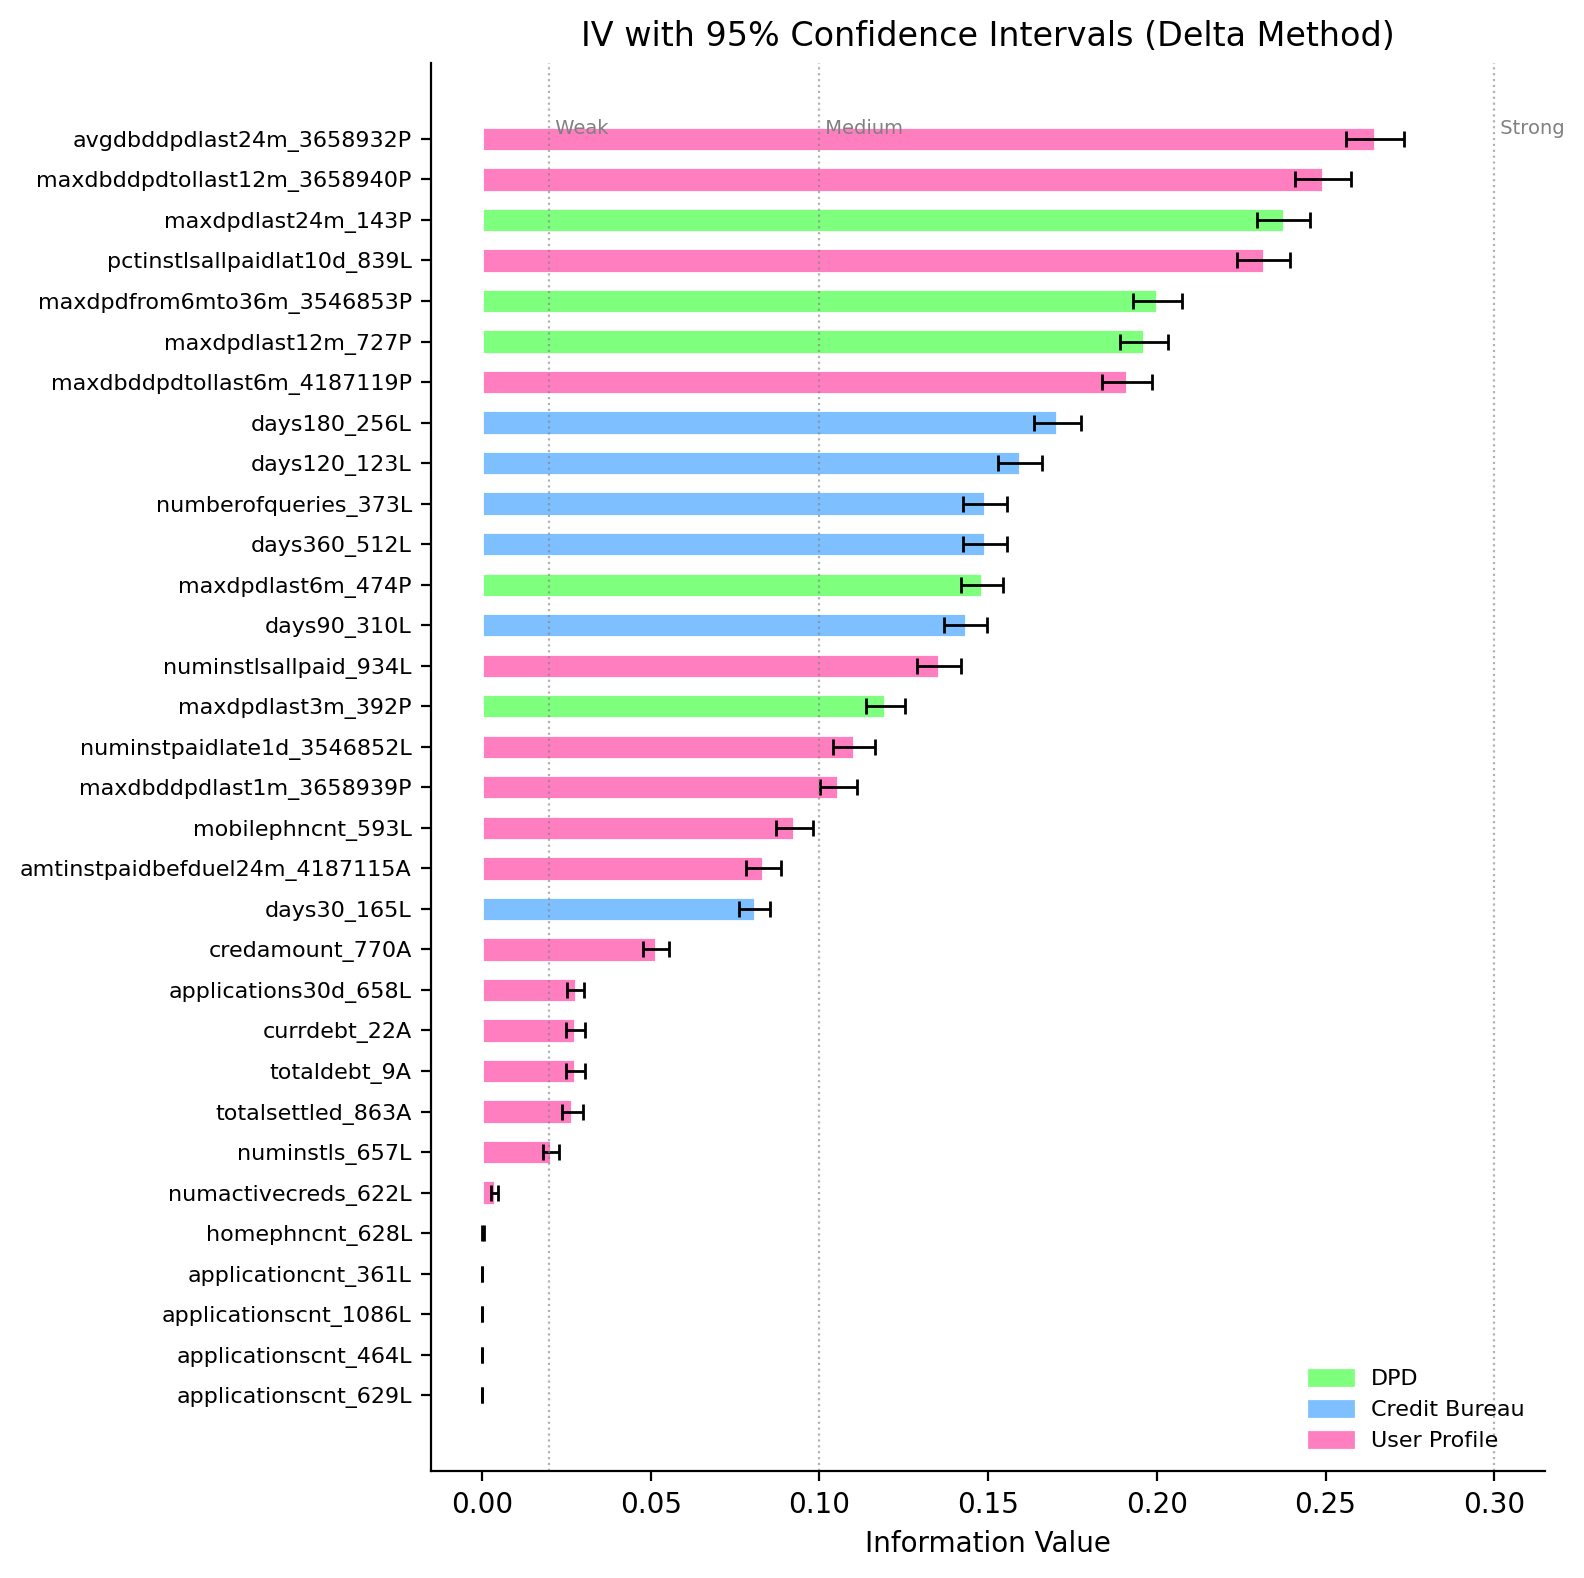

In [ ]:
# -------------------------------------------------------------------------------
# Figure: IV with 95% CIs, colored by feature group
# -------------------------------------------------------------------------------
group_colors = {}
for f in features_dpd:
    group_colors[f] = C_DPD
for f in features_cb:
    group_colors[f] = C_CB
for f in features_user:
    group_colors[f] = C_USER

fig, ax = plt.subplots(figsize=(8, 8))
y_pos = np.arange(len(iv_df))
bar_colors = [group_colors[f] for f in iv_df["feature"]]

ax.barh(
    y_pos,
    iv_df["iv"],
    xerr=1.96 * iv_df["se"],
    height=0.6,
    color=bar_colors,
    edgecolor="white",
    capsize=3,
    error_kw={"linewidth": 1, "color": "#333"},
)
ax.set_yticks(y_pos)
ax.set_yticklabels(iv_df["feature"], fontsize=8)
ax.set_xlabel("Information Value")
ax.set_title("IV with 95% Confidence Intervals (Delta Method)")

for thr, lab in [(0.02, "Weak"), (0.1, "Medium"), (0.3, "Strong")]:
    ax.axvline(thr, color="grey", ls=":", lw=0.8, alpha=0.6)
    ax.text(thr, len(iv_df) - 0.5, f" {lab}", fontsize=7, color="grey", va="top")

legend_patches = [
    Patch(color=C_DPD, label="DPD"),
    Patch(color=C_CB, label="Credit Bureau"),
    Patch(color=C_USER, label="User Profile"),
]
ax.legend(handles=legend_patches, loc="lower right", frameon=False, fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "iv_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Model performance and stability

We fit a logistic regression on WoE-transformed features — the natural scorecard in the IV framework — and examine Gini over time, DR vs PD, and feature group contributions.

In [ ]:
# -------------------------------------------------------------------------------
# WoE-transform all features and fit logistic regression
# -------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# Build WoE lookup from training set bins
woe_lookups: dict[str, dict[str, float]] = {}
for f in all_features:
    tbl = iv_results[f]["table"]
    woe_lookups[f] = dict(zip(tbl["bin"], tbl["woe"]))

def woe_transform(X_raw: pd.DataFrame, lookups: dict) -> pd.DataFrame:
    """Transform raw features to WoE values using pre-computed bin lookups."""
    out = pd.DataFrame(index=X_raw.index)
    for f in X_raw.columns:
        if X_raw[f].nunique() <= 10:
            binned = X_raw[f].astype(str)
        else:
            binned = pd.qcut(X_raw[f], q=10, duplicates="drop").astype(str)
        binned = binned.fillna("Missing")
        out[f] = binned.map(lookups[f]).fillna(0.0)
    return out

X_woe_train = woe_transform(X.loc[ix_train], woe_lookups)
X_woe_test = woe_transform(X.loc[ix_test], woe_lookups)
X_woe_all = woe_transform(X, woe_lookups)

lr = LogisticRegression(solver="lbfgs", penalty=None, max_iter=5000)
lr.fit(X_woe_train, y.loc[ix_train])

# Predictions
df["prediction"] = lr.predict_proba(X_woe_all)[:, 1]

gini_train = 2 * roc_auc_score(y.loc[ix_train], df.loc[ix_train, "prediction"]) - 1
gini_test = 2 * roc_auc_score(y.loc[ix_test], df.loc[ix_test, "prediction"]) - 1
print(f"Train Gini: {gini_train:.2%}")
print(f"Test Gini:  {gini_test:.2%}")

In [ ]:
# -------------------------------------------------------------------------------
# Figure: DR vs PD over time (through-the-economic-cycle)
# -------------------------------------------------------------------------------
df["date_decision"] = pd.to_datetime(df["date_decision"], errors="coerce")

df["target"].groupby(df["date_decision"]).mean().plot(
    kind="line", color=C_DR, linewidth=0.8, label="DR", rot=45,
    title="Through-the-economic-cycle split by week of origination",
)
df["prediction"].groupby(df["date_decision"]).mean().plot(
    kind="line", color=C_PD, linewidth=0.8, label="PD", rot=45,
)
plt.axhline(y=df["target"].mean(), color="r", linestyle="--", linewidth=0.5, label="Average DR")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES / "dr_vs_pd_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# -------------------------------------------------------------------------------
# Figure: Gini over time by WEEK_NUM
# -------------------------------------------------------------------------------
weekly_gini = []
for w in sorted(df["WEEK_NUM"].unique()):
    mask = df["WEEK_NUM"] == w
    yw, pw = y[mask], df.loc[mask, "prediction"]
    if yw.nunique() < 2 or len(yw) < 50:
        continue
    gini = 2 * roc_auc_score(yw, pw) - 1
    weekly_gini.append({"week": w, "gini": gini})

gini_df = pd.DataFrame(weekly_gini)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_df["week"], gini_df["gini"], "o-", color=C_PD, ms=4, lw=1.2)
ax.axhline(gini_df["gini"].mean(), color="grey", ls="--", lw=0.8,
           label=f"Mean Gini ({gini_df['gini'].mean():.2%})")
ax.set(xlabel="Week", ylabel="Gini", title="Gini Over Time (WoE Logistic Regression)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "gini_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# -------------------------------------------------------------------------------
# SHAP: feature importance (beeswarm) and group weights
# -------------------------------------------------------------------------------
import shap

explainer = shap.LinearExplainer(lr, X_woe_train)
shap_values = explainer.shap_values(X_woe_test)

# Beeswarm plot
fig = plt.figure(dpi=100)
shap.summary_plot(
    shap_values, X_woe_test, plot_type="dot",
    max_display=10, show=False, cmap="cool",
)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.savefig(IMAGES / "shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()

# Group weights from SHAP values
def shap_group_weight(shap_vals: np.ndarray, feature_names: pd.Index, group: list[str]) -> float:
    idxs = [feature_names.get_loc(f) for f in group if f in feature_names]
    return float(np.abs(shap_vals[:, idxs]).sum())

total_shap = sum(
    shap_group_weight(shap_values, X_woe_test.columns, g)
    for g in feature_groups.values()
)

print("\nSHAP group weights:")
for name, feats in feature_groups.items():
    w = shap_group_weight(shap_values, X_woe_test.columns, feats)
    print(f"  {name:20s}  {w/total_shap:6.1%}")

## 5. PSI over time with confidence intervals

PSI is the same Jeffreys divergence, now between a reference period and each subsequent week. The delta method gives the same SE, enabling confidence bands.

In [ ]:
# -------------------------------------------------------------------------------
# PSI over time for top-IV feature
# -------------------------------------------------------------------------------
top_feat = iv_df.iloc[-1]["feature"]
weeks = sorted(df["WEEK_NUM"].unique())
ref_weeks = weeks[:4]

series = df[top_feat]
if series.nunique() > 10:
    _, edges = pd.qcut(series.dropna(), q=10, duplicates="drop", retbins=True)
    edges[0], edges[-1] = -np.inf, np.inf
    binner = lambda s: pd.cut(s.fillna(-999), bins=edges).astype(str)
else:
    binner = lambda s: s.fillna(-999).astype(str)

ref_counts = binner(df.loc[df["WEEK_NUM"].isin(ref_weeks), top_feat]).value_counts()

psi_rows = []
for w in weeks:
    if w in ref_weeks:
        continue
    ws = df.loc[df["WEEK_NUM"] == w, top_feat]
    if len(ws) < 50:
        continue
    wc = binner(ws).value_counts()
    all_bins = sorted(set(ref_counts.index) | set(wc.index))
    r = np.array([ref_counts.get(b, 0) for b in all_bins], float)
    c = np.array([wc.get(b, 0) for b in all_bins], float)
    p = np.clip(r / r.sum(), 1e-15, None)
    q = np.clip(c / c.sum(), 1e-15, None)
    psi = float(((q - p) * np.log(q / p)).sum())
    se_ln = np.sqrt(1 / np.clip(r, 1, None) + 1 / np.clip(c, 1, None))
    se = float(np.sqrt(((q - p)**2 * se_ln**2).sum()))
    psi_rows.append({"week": w, "psi": psi, "se": se})

psi_df = pd.DataFrame(psi_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(psi_df["week"], psi_df["psi"], "o-", color=C_PD, ms=4, lw=1.5)
ax.fill_between(psi_df["week"],
                (psi_df["psi"] - 1.96 * psi_df["se"]).clip(lower=0),
                psi_df["psi"] + 1.96 * psi_df["se"],
                alpha=0.2, color=C_PD, label="95% CI")
ax.axhline(0.1, color="orange", ls="--", lw=1, label="Minor shift (0.1)")
ax.axhline(0.25, color="red", ls="--", lw=1, label="Major shift (0.25)")
ax.set(xlabel="Week", ylabel="PSI",
       title=f"PSI Over Time: {top_feat}\n(reference: weeks {ref_weeks})")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "psi_over_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Performance-fairness trade-off

The paper formalises the dual IV formulation (Section 6):

- **Maximise** $\text{IV}_\text{perf}(X)$ — Jeffreys divergence between good and bad (predictive power)
- **Minimise** $\text{IV}_\text{fair}(X)$ — Jeffreys divergence between protected groups (fairness)

Both are computed with the *same function* on different binary partitions. With standard errors, hard thresholds become probabilistic constraints:

$$P(\text{IV}_\text{fair} \leq \epsilon) \geq 95\%$$

In [17]:
# -------------------------------------------------------------------------------
# Compute predictive IV and demographic IV (vs. sex) for each feature
# -------------------------------------------------------------------------------
n_F = (sex_binary.loc[ix_train] == 0).sum()
n_M = (sex_binary.loc[ix_train] == 1).sum()

fairness = []
for f in all_features:
    pred_iv = iv_df.loc[iv_df["feature"] == f, "iv"].values[0]
    pred_se = iv_df.loc[iv_df["feature"] == f, "se"].values[0]

    tbl_d, demo_iv = compute_woe_iv(X.loc[ix_train, f], sex_binary.loc[ix_train])
    _, demo_se = iv_standard_error(tbl_d["n_good"].values, tbl_d["n_bad"].values, n_F, n_M)

    fairness.append(
        {
            "feature": f,
            "pred_iv": pred_iv,
            "pred_se": pred_se,
            "demo_iv": demo_iv,
            "demo_se": demo_se,
        }
    )

fair_df = pd.DataFrame(fairness).sort_values("pred_iv", ascending=False).reset_index(drop=True)
fair_df[["feature", "pred_iv", "pred_se", "demo_iv", "demo_se"]]

,feature,pred_iv,pred_se,demo_iv,demo_se
0,avgdbddpdlast24m_3658932P,0.264680,0.004364,0.038099,0.000666
1,maxdbddpdtollast12m_3658940P,0.249174,0.004264,0.043210,0.000713
2,maxdpdlast24m_143P,0.237605,0.003967,0.028312,0.000577
3,pctinstlsallpaidlat10d_839L,0.231644,0.004052,0.040049,0.000684
4,maxdpdfrom6mto36m_3546853P,0.200169,0.003663,0.029722,0.000592
5,maxdpdlast12m_727P,0.196215,0.003633,0.023500,0.000524
6,maxdbddpdtollast6m_4187119P,0.191077,0.003755,0.039756,0.000686
7,days180_256L,0.170479,0.003540,0.007475,0.000294
8,days120_123L,0.159486,0.003370,0.006262,0.000269
9,numberofqueries_373L,0.149172,0.003303,0.010877,0.000354


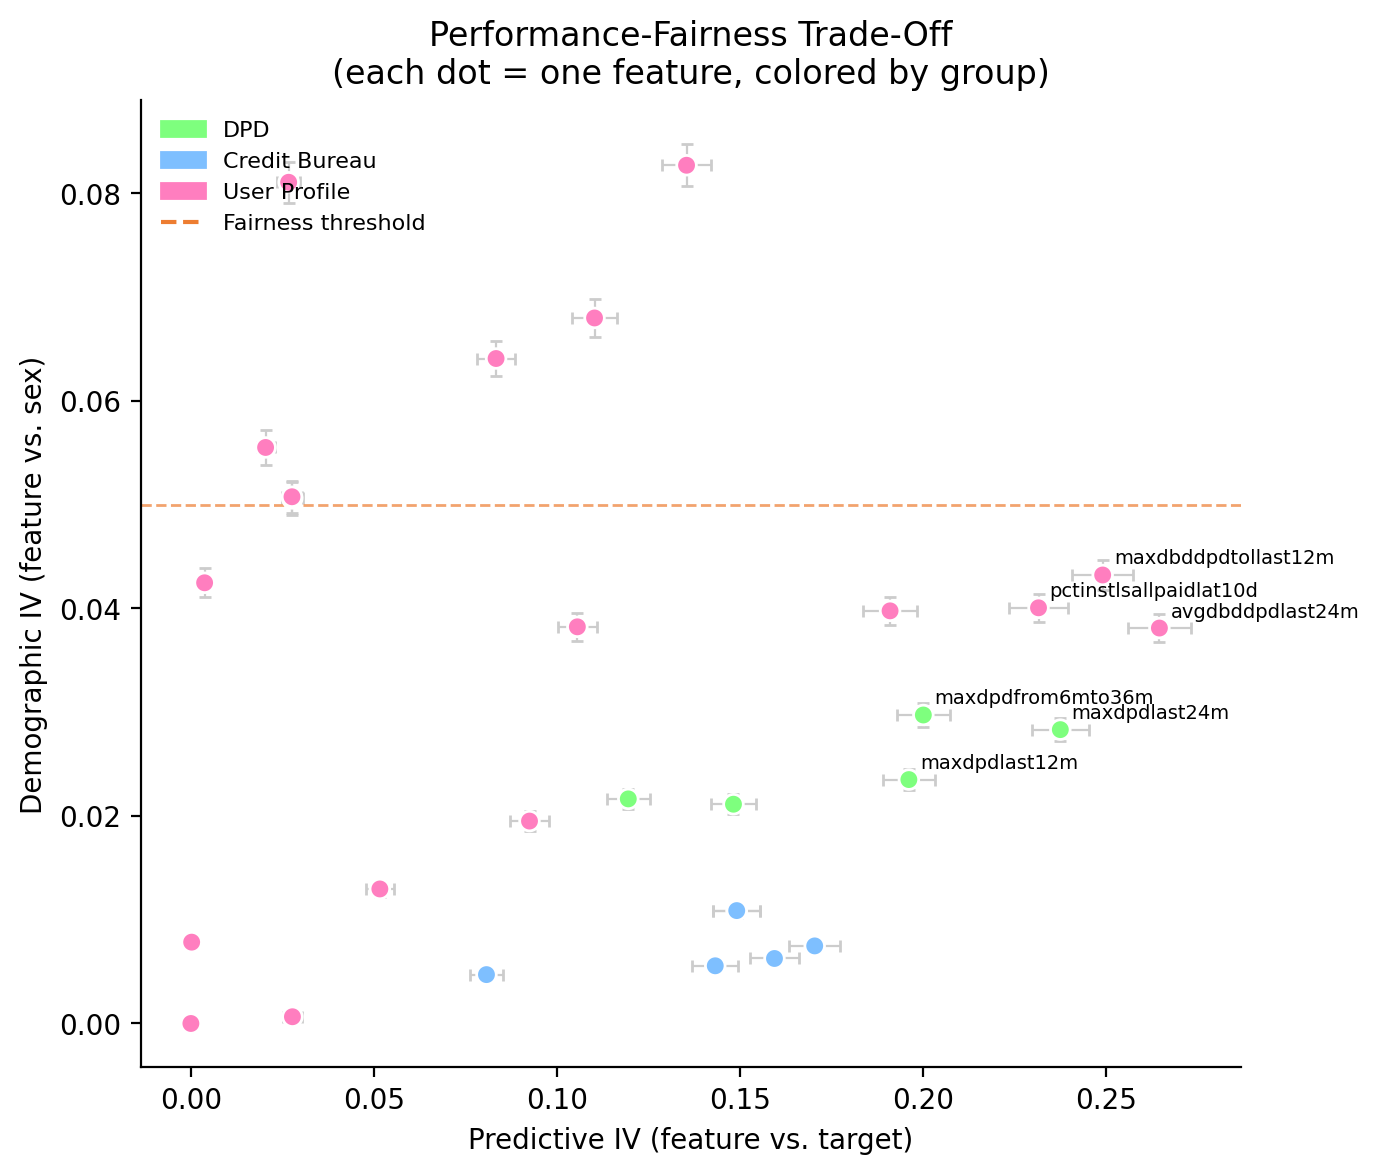

In [ ]:
# -------------------------------------------------------------------------------
# Figure: Predictive IV vs Demographic IV (Pareto trade-off)
# -------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

# Color by group
scatter_colors = [group_colors.get(f, C_IV) for f in fair_df["feature"]]
ax.scatter(
    fair_df["pred_iv"], fair_df["demo_iv"], c=scatter_colors, s=50, edgecolors="white", zorder=3
)
ax.errorbar(
    fair_df["pred_iv"],
    fair_df["demo_iv"],
    xerr=1.96 * fair_df["pred_se"],
    yerr=1.96 * fair_df["demo_se"],
    fmt="none",
    ecolor="#ccc",
    elinewidth=0.8,
    capsize=2,
    zorder=2,
)

for _, r in fair_df.head(6).iterrows():
    ax.annotate(
        r["feature"].split("_")[0],
        (r["pred_iv"], r["demo_iv"]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )

# Fairness threshold line
ax.axhline(0.05, color=C_FAIR, ls="--", lw=1, alpha=0.7, label=f"Fairness threshold (IV=0.05)")

legend_patches = [
    Patch(color=C_DPD, label="DPD"),
    Patch(color=C_CB, label="Credit Bureau"),
    Patch(color=C_USER, label="User Profile"),
]
ax.legend(
    handles=legend_patches
    + [plt.Line2D([0], [0], color=C_FAIR, ls="--", label="Fairness threshold")],
    loc="upper left",
    frameon=False,
    fontsize=8,
)

ax.set(
    xlabel="Predictive IV (feature vs. target)",
    ylabel="Demographic IV (feature vs. sex)",
    title="Performance-Fairness Trade-Off\n(each dot = one feature, colored by group)",
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES / "pareto_predictive_vs_demographic.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
# -------------------------------------------------------------------------------
# Probabilistic fairness constraint: P(IV_demographic <= epsilon) >= 95%
# -------------------------------------------------------------------------------
epsilon = 0.05

fair_df["p_fair"] = stats.norm.cdf(
    epsilon, loc=fair_df["demo_iv"], scale=fair_df["demo_se"].clip(lower=1e-15)
)

# Show only features that FAIL the fairness test
flagged = fair_df[fair_df["p_fair"] < 0.95].copy()
flagged["upper_95"] = flagged["demo_iv"] + 1.96 * flagged["demo_se"]

print(f"Fairness threshold: IV_demo <= {epsilon} at 95% confidence")
print(f"Features flagged: {len(flagged)} / {len(fair_df)}\n")
print(
    flagged[["feature", "pred_iv", "demo_iv", "demo_se", "upper_95", "p_fair"]].to_string(
        index=False
    )
)

Fairness threshold: IV_demo <= 0.05 at 95% confidence
Features flagged: 7 / 32

                       feature  pred_iv  demo_iv  demo_se  upper_95        p_fair
         numinstlsallpaid_934L 0.135457 0.082686 0.001034  0.084712 8.302060e-220
    numinstpaidlate1d_3546852L 0.110313 0.067974 0.000926  0.069790  3.509524e-84
amtinstpaidbefduel24m_4187115A 0.083404 0.064066 0.000882  0.065795  1.562098e-57
                  currdebt_22A 0.027698 0.050589 0.000795  0.052148  2.293026e-01
                  totaldebt_9A 0.027634 0.050747 0.000795  0.052306  1.736531e-01
             totalsettled_863A 0.026722 0.081047 0.001002  0.083011 3.977107e-211
                numinstls_657L 0.020416 0.055497 0.000839  0.057142  2.891481e-11
